In [1]:
import os
import re
import io
import tempfile
from pathlib import Path
import fitz  # PyMuPDF
from PIL import Image
from typhoon_ocr import ocr_document

try:
    from dotenv import load_dotenv
    load_dotenv()
    print('dotenv loaded')
except ImportError:
    print('python-dotenv not installed; skipping .env load')


dotenv loaded


In [2]:
NOTEBOOK_DIR = Path().resolve()
SOURCE_DIR = Path(os.getenv("SOURCE_DIR", str(NOTEBOOK_DIR.parent / "source" / "เขตเลือกตั้งที่ 2")))

PDF_DPI = 200
TARGET_FORM = "ส.ส.5ทับ18.pdf"

TYPHOON_API_KEY = os.getenv("TYPHOON_OCR_API_KEY")

env_path = NOTEBOOK_DIR.parent / ".env"
if not env_path.exists():
    print(f"WARNING: .env not found — copy .env.example to .env and set your API key")

print(f"SOURCE_DIR: {SOURCE_DIR}")
print(f"SOURCE_DIR exists: {SOURCE_DIR.exists()}")
print(f"Typhoon API key set: {bool(TYPHOON_API_KEY)}")
print(f"Target form: {TARGET_FORM}, DPI: {PDF_DPI}")


SOURCE_DIR: /home/chatrin/Documents/Chat/CU/Year-3/2110446_DSDE_2025s2/final-project/source/เขตเลือกตั้งที่ 2
SOURCE_DIR exists: True
Typhoon API key set: True
Target form: ส.ส.5ทับ18.pdf, DPI: 200


In [3]:
def crop_pdf_page_to_image(
    pdf_path: str,
    page_num: int = 1,
    dpi: int = 200,
    crop_top_ratio: float = 0.35,
    crop_bottom_ratio: float = 1.0,
) -> str:
    """Render a PDF page, crop to the region of interest, save as temp JPEG.

    crop_top_ratio=0.35 skips the header (title + preamble text),
    keeping the statistics and candidate vote table.
    Returns the path to the saved temp file.
    """
    doc = fitz.open(pdf_path)
    page = doc[page_num - 1]
    mat = fitz.Matrix(dpi / 72, dpi / 72)
    pix = page.get_pixmap(matrix=mat, colorspace=fitz.csRGB)
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    doc.close()

    h = img.height
    top = int(h * crop_top_ratio)
    bottom = int(h * crop_bottom_ratio)
    cropped = img.crop((0, top, img.width, bottom))

    tmp = tempfile.NamedTemporaryFile(suffix=".jpg", delete=False)
    cropped.save(tmp.name, "JPEG", quality=95)
    tmp.close()
    return tmp.name


def run_typhoon_ocr_cropped(
    pdf_path: str,
    page_num: int = 1,
    crop_top_ratio: float = 0.35,
    dpi: int = 200,
) -> str:
    """Crop the PDF page to the data region, then call Typhoon OCR on the crop.

    Sending a smaller image reduces API latency and improves accuracy by
    focusing the model on the statistics + candidate table only.
    """
    cropped_path = crop_pdf_page_to_image(
        pdf_path, page_num=page_num, dpi=dpi, crop_top_ratio=crop_top_ratio
    )
    try:
        result = ocr_document(
            pdf_or_image_path=cropped_path,
            figure_language="Thai",
        )
    finally:
        os.unlink(cropped_path)  # clean up temp file
    return result


Cropped image size: (1240, 1141)


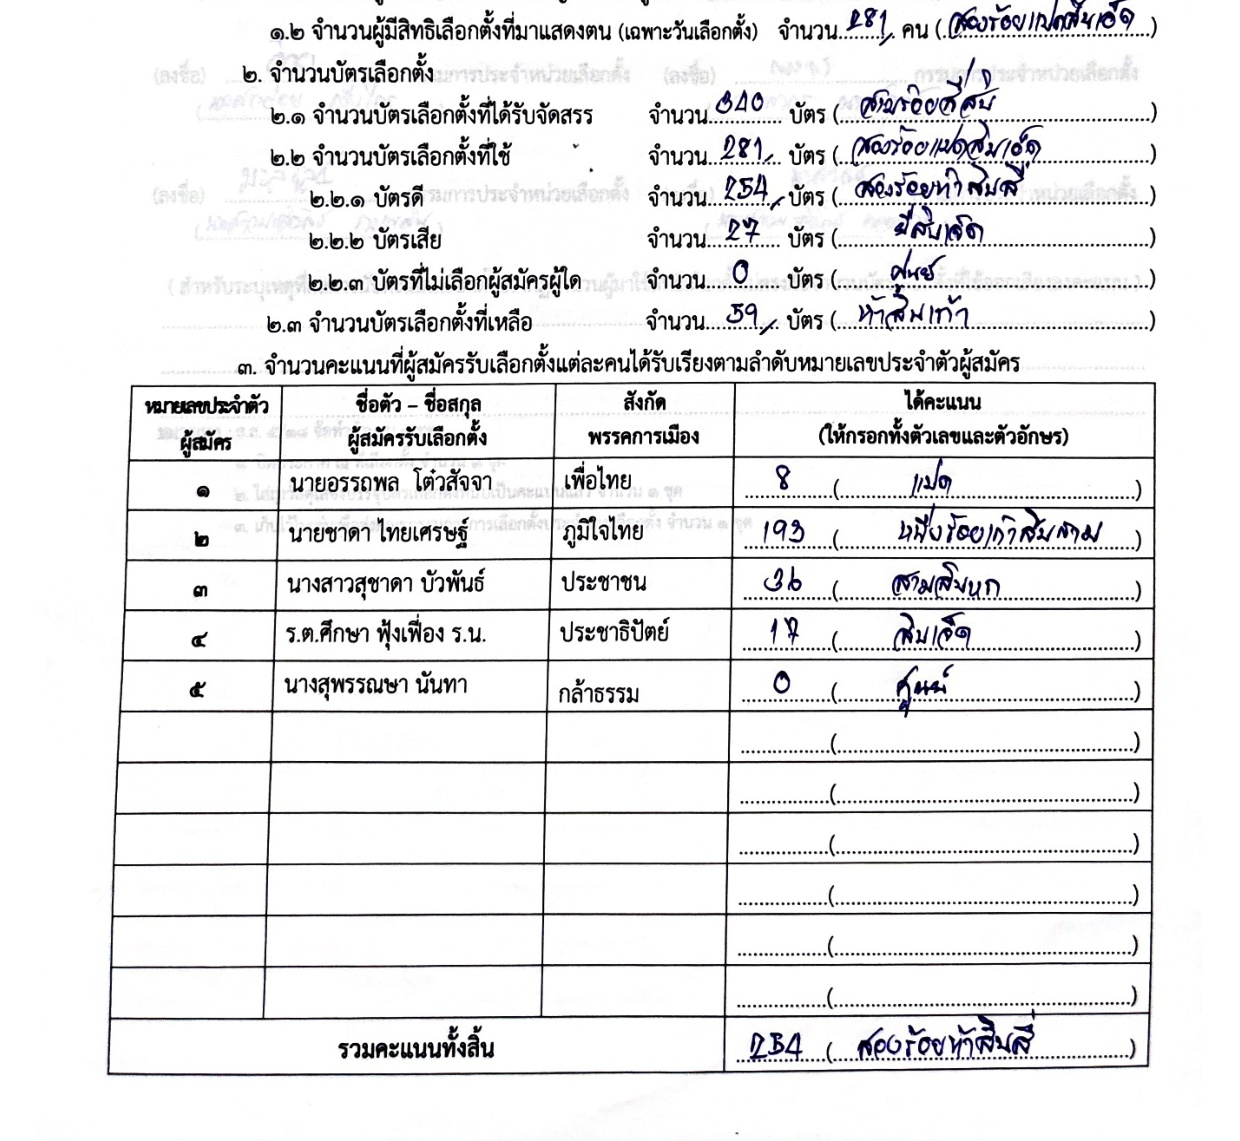

In [5]:
# Visual check: preview the cropped region before sending to API
import matplotlib.pyplot as plt
from IPython.display import display

pdf_path = str(NOTEBOOK_DIR / "test_images" / "ส.ส.5ทับ18.pdf")
cropped_path = crop_pdf_page_to_image(pdf_path, crop_top_ratio=0.35, dpi=150)
img = Image.open(cropped_path)
print(f"Cropped image size: {img.size}")
display(img)
os.unlink(cropped_path)


In [6]:
# Run Typhoon OCR on the cropped election form
pdf_path = str(NOTEBOOK_DIR / "test_images" / "ส.ส.5ทับ18.pdf")
print(f"Running OCR on: {pdf_path}")
result = run_typhoon_ocr_cropped(pdf_path, page_num=1, crop_top_ratio=0.35)
print(result)


Running OCR on: /home/chatrin/Documents/Chat/CU/Year-3/2110446_DSDE_2025s2/final-project/notebooks/test_images/ส.ส.5ทับ18.pdf
๑.๒ จำนวนผู้มีสิทธิเลือกตั้งที่มาแสดงตน (เฉพาะวันเลือกตั้ง) จำนวน 281 คน (สองร้อยแปดสิบเอ็ด)
๒. จำนวนบัตรเลือกตั้ง
๒.๑ จำนวนบัตรเลือกตั้งที่ได้รับจัดสรร จำนวน 340 บัตร (สามร้อยสี่สิบ)
๒.๒ จำนวนบัตรเลือกตั้งที่ใช้ จำนวน 281 บัตร (สองร้อยแปดสิบเอ็ด)
๒.๒.๑ บัตรดี จำนวน 254 บัตร (สองร้อยห้าสิบสี่)
๒.๒.๒ บัตรเสีย จำนวน 27 บัตร (สี่สิบเจ็ด)
๒.๒.๓ บัตรที่ไม่เลือกผู้สมัครผู้ใด จำนวน 0 บัตร (ศูนย์)
๒.๓ จำนวนบัตรเลือกตั้งที่เหลือ จำนวน 59 บัตร (ห้าสิบเก้า)

๓. จำนวนคะแนนที่ผู้สมัครรับเลือกตั้งแต่ละคนได้รับเรียงตามลำดับหมายเลขประจำตัวผู้สมัคร

<table><tr><td>หมายเลขประจำตัว ผู้สมัคร</td><td>ชื่อตัว - ชื่อสกุล ผู้สมัครรับเลือกตั้ง</td><td>สังกัด พรรคการเมือง</td><td>ได้คะแนน (ให้กรอกทั้งตัวเลขและตัวอักษร)</td></tr><tr><td>๑</td><td>นายอรรถพล โต๋วสัจจา</td><td>เพื่อไทย</td><td>8 (แปด)</td></tr><tr><td>๒</td><td>นายชาดา ไทยเศรษฐ์</td><td>ภูมิใจไทย</td><td>193 (หนึ่งร้อยเก้าสิ

In [7]:
# Test with the invoice image (no crop needed for non-PDF)
invoice_path = str(NOTEBOOK_DIR / "test_images" / "invoice.jpg")
print(f"Running OCR on: {invoice_path}")
result_invoice = ocr_document(
    pdf_or_image_path=invoice_path,
    figure_language="Thai",
)
print(result_invoice)


Running OCR on: /home/chatrin/Documents/Chat/CU/Year-3/2110446_DSDE_2025s2/final-project/notebooks/test_images/invoice.jpg
MIXUE SINCE 1997 ICE CREAM &amp; TEA

ทวนในร้าน#147

หมายเลขเอกสาร: 240809203010347
เวลาสั่งซื้อ: 2024-08-09 20:29:57

<table><tr><td>ชื่อ</td><td>ราคาต่อหน่วย</td><td>จำนวน</td><td>รวม</td></tr><tr><td>สตอเบอรี่ ซันเดย์ Strawberry Sundae</td><td>35.00</td><td>1</td><td>35.00</td></tr></table>

รวม 1 35.00
จำนวนเงินที่ไม่รวมภาษี 32.71
VAT(7.00%) 2.29
ต้องเก็บ 35.00

1.PromptPay 35.00

พนักงานรับเงิน: 81120021901
ที่อยู่: เลขที่ 239/52 หมู่ที่ 3
จังหวัด: โทรสำพท์: 0
เวลา: 2024-08-09 20:30:04
